# Surface Analysis for the 2011 Super Outbreak

This notebook will map station plots to see how the 2011 Super Outbreak was handled in comparison to the reanalysis.
Most of this code is from the surface-plots notebook from ATM350.

In [13]:
from datetime import datetime,timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from metpy.calc import wind_components, reduce_point_density
from metpy.units import units
from metpy.plots import StationPlot
from metpy.plots.wx_symbols import current_weather, sky_cover, wx_code_map

# Load in a collection of functions that process GEMPAK weather conditions and cloud cover data.
%run /kt11/ktyle/python/metargem.py

In [37]:
validTime = datetime(2011, 4, 26, 12)
year = 2011
month = 4
day = 26
hour = 12
minute = 0

timeStr = validTime.strftime("%Y-%m-%d %H UTC")
timeStr2 = validTime.strftime("%Y%m%d%H")
YYMMDDHH = validTime.strftime("%y%m%d%H")
print(timeStr)
print(validTime)

2011-04-26 12 UTC
2011-04-26 12:00:00


In [38]:
metarFile = f'/ktyle_rit/scripts/sflist2/complete/{YYMMDDHH}.csv'
df = pd.read_csv(metarFile, sep='\\s+')

# i know this code cell isn't working, but ideally it would run the rest of the code! 
# if there is a different way to access ASOS data, please let me know

FileNotFoundError: [Errno 2] No such file or directory: '/ktyle_rit/scripts/sflist2/complete/11042612.csv'

In [39]:
df

,STN,YYMMDD/HHMM,SLAT,SLON,SELV,PMSL,ALTI,TMPC,DWPC,SKNT,...,P03C,CTYL,CTYM,CTYH,P06I,T6XC,T6NC,CEIL,P01I,SNEW
0,04V,221224/1800,38.10,-106.17,2385.0,-9999.0,30.37,2.0,-7.0,14.0,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
1,0CO,221224/1800,39.79,-105.76,3807.0,-9999.0,30.30,-11.0,-12.0,29.0,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,3.0,-9999.0,-9999.0
2,0J4,221224/1800,31.04,-86.31,96.0,1032.0,30.47,-1.7,-15.0,4.0,...,-1.9,-9999.0,-9999.0,-9999.0,-9999.0,-1.7,-8.3,-9999.0,-9999.0,-9999.0
3,11R,221224/1800,30.22,-96.37,94.0,-9999.0,-9999.00,0.8,-13.9,6.0,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,1.0,-7.2,-9999.0,-9999.0,-9999.0
4,12N,221224/1800,41.01,-74.74,178.0,1009.9,29.76,-11.7,-20.0,9.0,...,-0.1,-9999.0,-9999.0,-9999.0,-9999.0,-11.1,-15.0,-9999.0,-9999.0,-9999.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3678,BNL,221224/1800,-9999.00,-9999.00,-9999.0,-9999.0,30.25,-4.0,-17.0,10.0,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
3679,HFY,221224/1800,-9999.00,-9999.00,-9999.0,-9999.0,30.06,-11.2,-15.5,14.0,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-11.2,-17.0,23.0,-9999.0,-9999.0
3680,LDJ,221224/1800,-9999.00,-9999.00,-9999.0,-9999.0,29.82,-9.8,-21.7,14.0,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9.4,-14.0,-9999.0,-9999.0,-9999.0
3681,RNV,221224/1800,-9999.00,-9999.00,-9999.0,-9999.0,30.55,-3.8,-14.1,6.0,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-3.6,-9.5,-9999.0,-9999.0,-9999.0


In [40]:
# set the bounds
lonW = -105
lonE = -75
latS = 28
latN = 42
cLat, cLon = (latS + latN)/2, (lonW + lonE)/2

df2 = df.query('SLAT >= @latS & SLAT <= @latN  & SLON >= @lonW  & SLON <= @lonE')
df2

,STN,YYMMDD/HHMM,SLAT,SLON,SELV,PMSL,ALTI,TMPC,DWPC,SKNT,...,P03C,CTYL,CTYM,CTYH,P06I,T6XC,T6NC,CEIL,P01I,SNEW
2,0J4,221224/1800,31.04,-86.31,96.0,1032.0,30.47,-1.7,-15.0,4.0,...,-1.9,-9999.0,-9999.0,-9999.0,-9999.0,-1.7,-8.3,-9999.0,-9999.0,-9999.0
3,11R,221224/1800,30.22,-96.37,94.0,-9999.0,-9999.00,0.8,-13.9,6.0,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,1.0,-7.2,-9999.0,-9999.0,-9999.0
5,1A5,221224/1800,35.22,-83.42,616.0,-9999.0,30.12,-5.9,-15.3,8.0,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-5.9,-16.4,-9999.0,-9999.0,-9999.0
6,1F0,221224/1800,34.17,-97.12,257.0,-9999.0,30.58,-1.6,-17.8,7.0,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-1.4,-10.3,-9999.0,-9999.0,-9999.0
7,1H2,221224/1800,39.07,-88.53,179.0,-9999.0,30.22,-8.6,-15.9,14.0,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-8.6,-15.0,-9999.0,-9999.0,-9999.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3129,WLD,221224/1800,37.17,-97.03,351.0,1036.7,30.55,-6.7,-17.2,5.0,...,-0.4,-9999.0,-9999.0,-9999.0,-9999.0,-6.7,-14.4,-9999.0,-9999.0,-9999.0
3207,WRB,221224/1800,32.63,-83.60,90.0,1027.8,30.33,-3.7,-15.7,9.0,...,-1.8,-9999.0,-9999.0,-9999.0,-9999.0,-3.5,-10.6,-9999.0,-9999.0,-9999.0
3347,XNA,221224/1800,36.28,-94.31,392.0,1035.2,30.50,-8.3,-16.7,8.0,...,-0.2,-9999.0,-9999.0,-9999.0,-9999.0,-7.8,-14.4,-9999.0,-9999.0,-9999.0
3466,YNG,221224/1800,41.27,-80.67,361.0,1011.0,29.76,-16.1,-20.6,14.0,...,0.6,-9999.0,-9999.0,-9999.0,0.0,-16.1,-17.8,23.0,0.0,-9999.0


In [41]:
columns = ['STN', 'YYMMDD/HHMM', 'SLAT', 'SLON', 'SELV', 'TMPC', 'DWPC', 'PMSL',
                'SKNT', 'DRCT','ALTI','WNUM','VSBY','CHC1', 'CHC2', 'CHC3','CTYH', 'CTYM', 'CTYL']
df3 = df2[columns]
df3

,STN,YYMMDD/HHMM,SLAT,SLON,SELV,TMPC,DWPC,PMSL,SKNT,DRCT,ALTI,WNUM,VSBY,CHC1,CHC2,CHC3,CTYH,CTYM,CTYL
2,0J4,221224/1800,31.04,-86.31,96.0,-1.7,-15.0,1032.0,4.0,-9999.0,30.47,-9999.00,10.0,1.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
3,11R,221224/1800,30.22,-96.37,94.0,0.8,-13.9,-9999.0,6.0,340.0,-9999.00,-9999.00,10.0,1.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
5,1A5,221224/1800,35.22,-83.42,616.0,-5.9,-15.3,-9999.0,8.0,360.0,30.12,-9999.00,10.0,1.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
6,1F0,221224/1800,34.17,-97.12,257.0,-1.6,-17.8,-9999.0,7.0,340.0,30.58,-9999.00,10.0,1.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
7,1H2,221224/1800,39.07,-88.53,179.0,-8.6,-15.9,-9999.0,14.0,250.0,30.22,-9999.00,10.0,1.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3129,WLD,221224/1800,37.17,-97.03,351.0,-6.7,-17.2,1036.7,5.0,290.0,30.55,-9999.00,10.0,1.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
3207,WRB,221224/1800,32.63,-83.60,90.0,-3.7,-15.7,1027.8,9.0,280.0,30.33,-9999.00,10.0,1.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
3347,XNA,221224/1800,36.28,-94.31,392.0,-8.3,-16.7,1035.2,8.0,280.0,30.50,-9999.00,10.0,1.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
3466,YNG,221224/1800,41.27,-80.67,361.0,-16.1,-20.6,1011.0,14.0,220.0,29.76,32.00,1.0,156.0,234.0,-9999.0,-9999.0,-9999.0,-9999.0


In [42]:
# replacing missing values into a readable format
df4 = df3.replace(-9999.0, np.nan)
data1 = df4

In [43]:
data1.loc[data1['WNUM'] =='********', ['WNUM']] = '-9999.00'
data1['WNUM'] = data1['WNUM'].astype('float16')

In [44]:
lats = data1['SLAT'].values
lons = data1['SLON'].values
tair = (data1['TMPC'].values * units ('degC')).to('degF')
dewp = (data1['DWPC'].values * units ('degC')).to('degF')
altm = (data1['ALTI'].values * units('inHg')).to('mbar')
slp = data1['PMSL'].values * units('hPa')

# separate wind to components
u, v = wind_components(data1['SKNT'].values * units.knots, data1['DRCT'].values * units.degree)

# Need to handle missing (NaN) and convert to proper code
chc1 = (np.nan_to_num(data1['CHC1'].values,True).astype(int))
chc2 = (np.nan_to_num(data1['CHC2'].values,True).astype(int))
chc3 = (np.nan_to_num(data1['CHC3'].values,True).astype(int))
cloud_cover = calc_clouds(chc1, chc2, chc3)

# set a variable for plotting the station id's
stid = data1['STN']

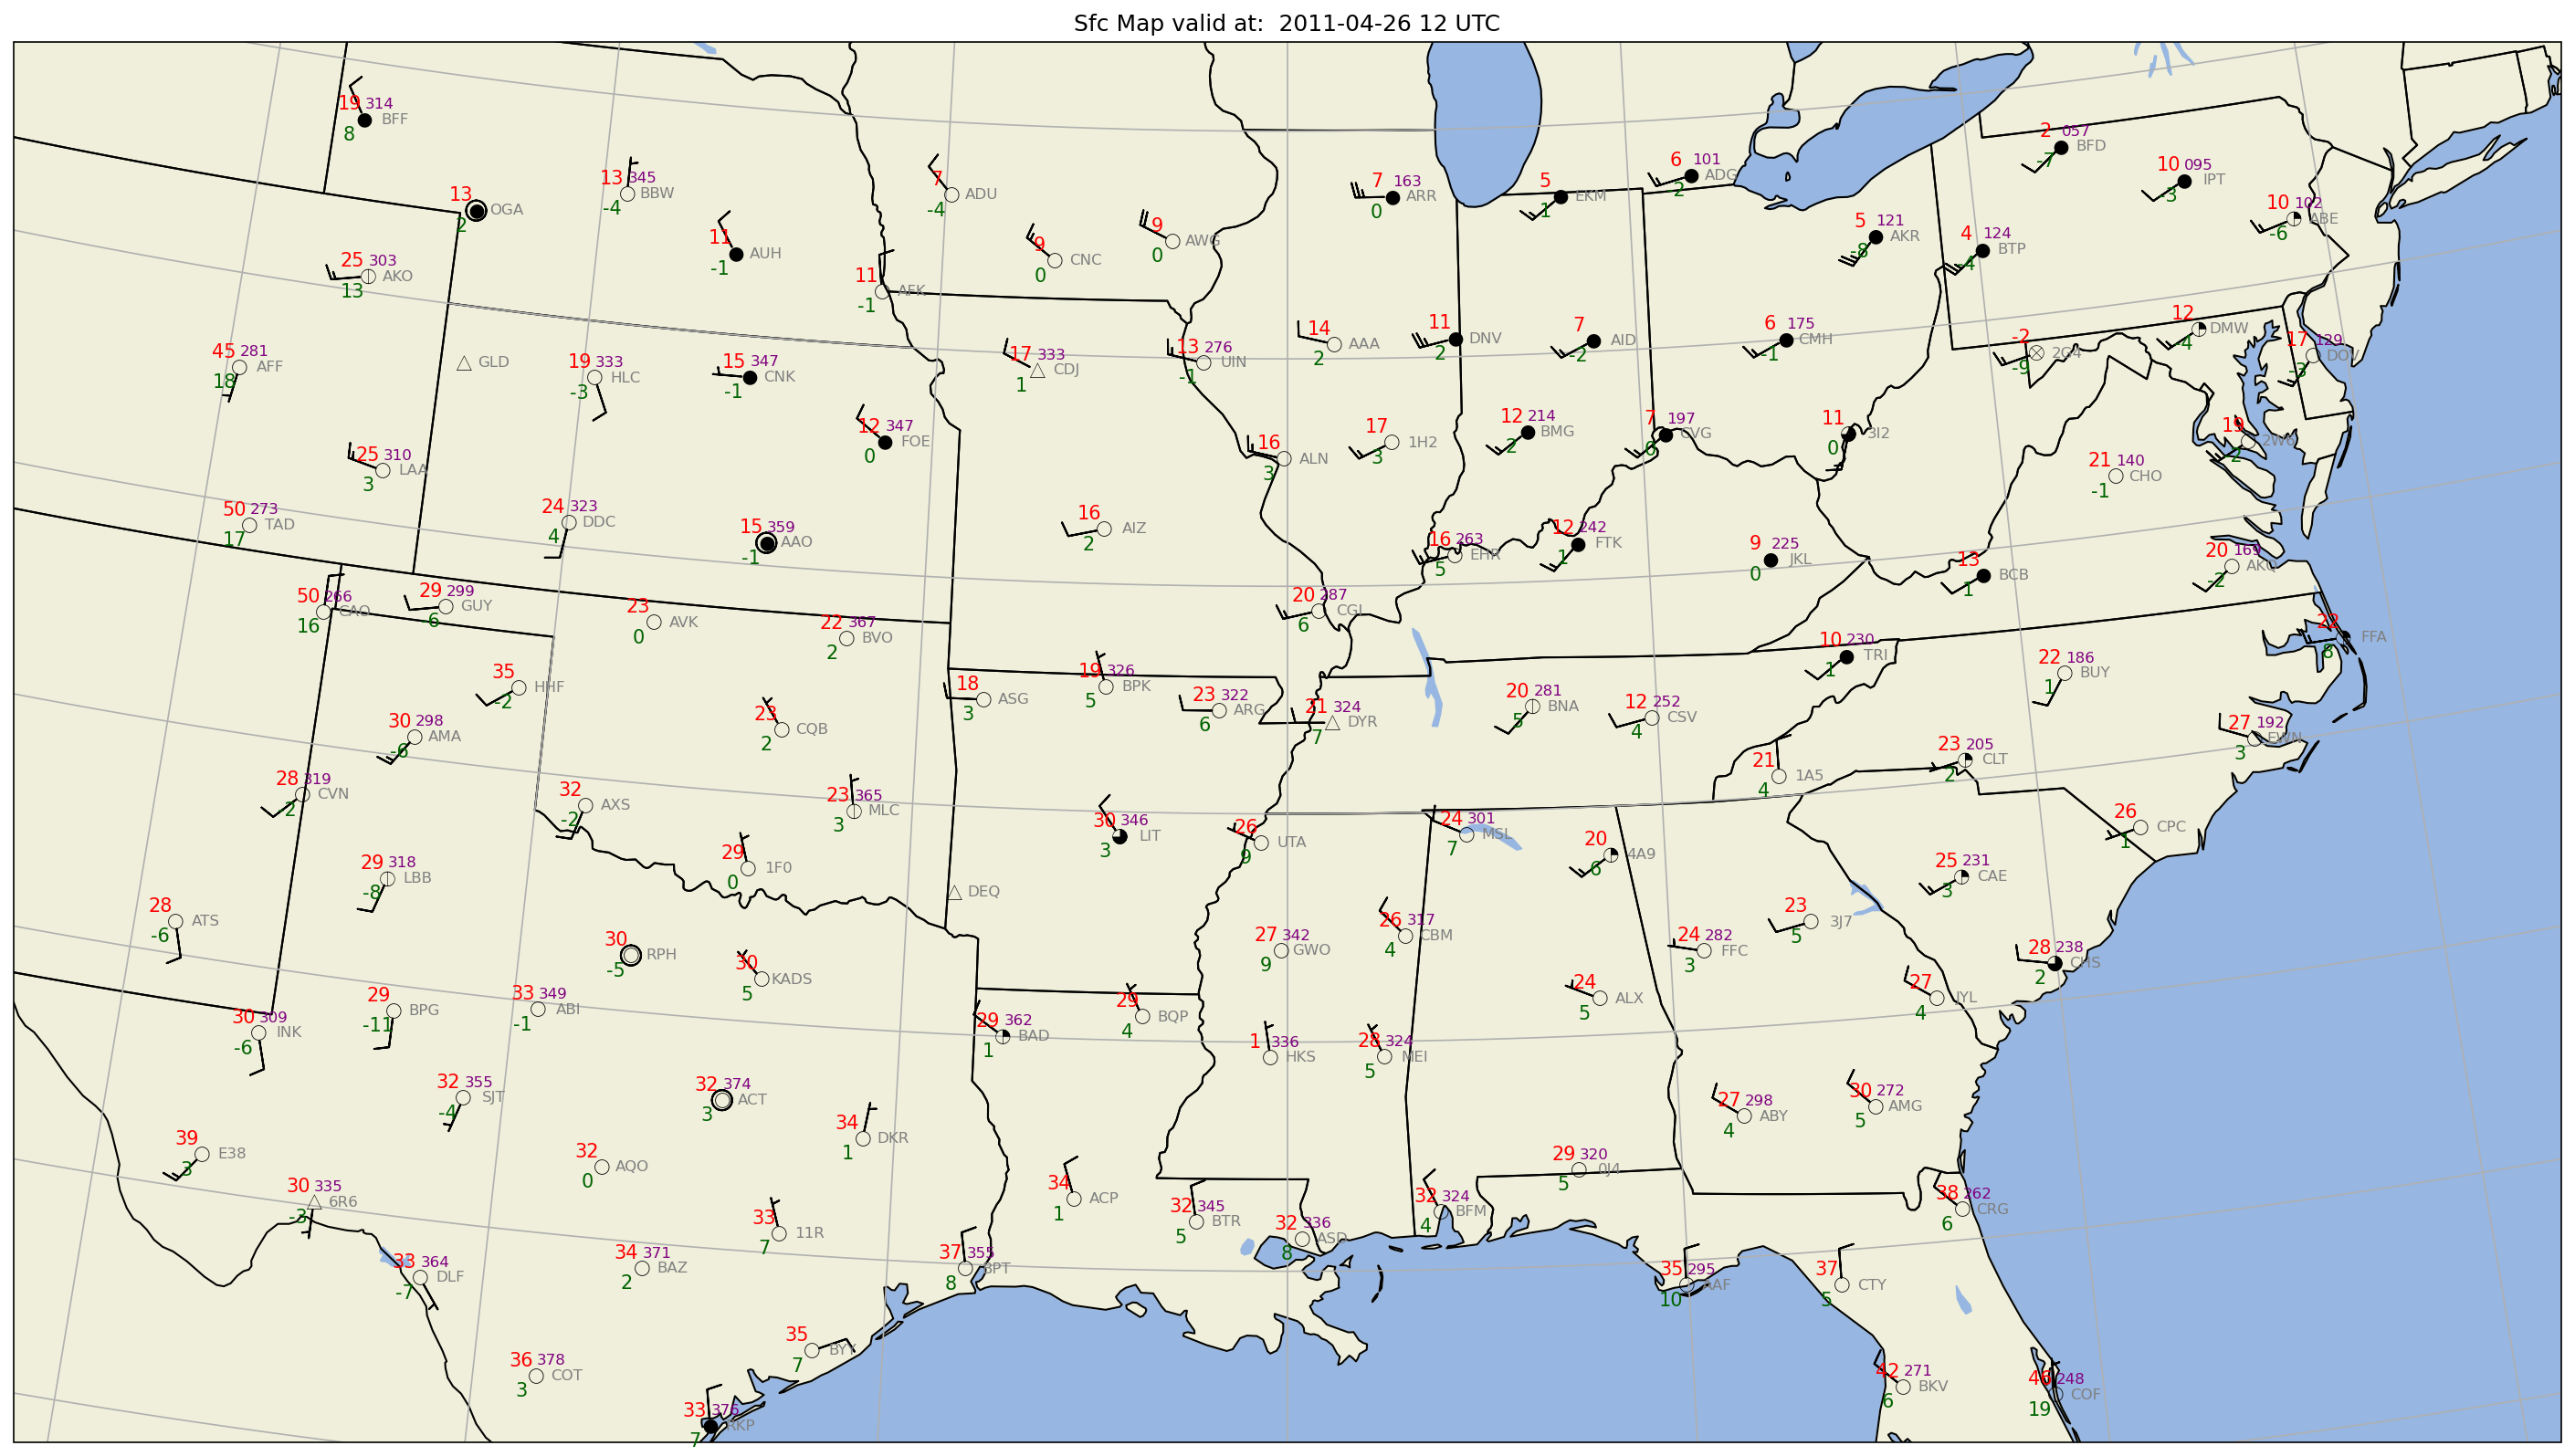

In [45]:
proj_map = ccrs.LambertConformal(central_longitude=cLon, central_latitude=cLat)
proj_data = ccrs.PlateCarree() 
res = '50m'

xy = proj_map.transform_points(proj_data, lons, lats)

density = 130000
mask = reduce_point_density(xy, density)
dpi = 150

fig = plt.figure(figsize=(24,18), dpi=dpi)

ax = fig.add_subplot(1, 1, 1, projection=proj_map)

ax.set_extent ((lonW-0.5,lonE+0.5,latS-0.5,latN+0.5), crs=proj_data)

ax.set_facecolor(cfeature.COLORS['water'])
land_mask = cfeature.NaturalEarthFeature('physical', 'land', res, edgecolor='face', facecolor=cfeature.COLORS['land'])
lake_mask = cfeature.NaturalEarthFeature('physical', 'lakes', res, edgecolor='face', facecolor=cfeature.COLORS['water'])
state_borders = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale=res, facecolor='none')

ax.add_feature(land_mask)
ax.add_feature(lake_mask)
ax.add_feature(state_borders, linestyle='solid', edgecolor='black')
ax.gridlines()

stationplot = StationPlot(ax, lons[mask], lats[mask], transform=proj_data,
                          fontsize=8)

stationplot.plot_parameter('NW', tair[mask], color='red', fontsize=10)
stationplot.plot_parameter('SW', dewp[mask], color='darkgreen', fontsize=10)

stationplot.plot_parameter('NE', slp[mask], color='purple', formatter=lambda v: format(10 * v, '.0f')[-3:])



stationplot.plot_symbol('C', cloud_cover[mask], sky_cover)
stationplot.plot_text((2, 0),stid[mask], color='gray')
#zorder - Higher value zorder will plot the variable on top of lower value zorder. This is necessary for wind barbs to appear. Default is 1.
stationplot.plot_barb(u[mask], v[mask],zorder=2)

plotTitle = (f"Sfc Map valid at:  {timeStr}")
ax.set_title (plotTitle);